Problem Statment
1. The problem statment is what are the AQI levels in differnt cities throughout the country? 
2. What are the mojor pollutantants ?
3. What are the major factors effect the AQI levels ?
4. What are the best ways to reduce the AQI levels

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import streamlit as st

In [47]:
st.title("Air Quality Analysis Dashboard")

2026-06-12 14:33:49.111 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-12 14:33:49.445 
  command:

    streamlit run c:\Users\daraq\Downloads\EDA\myenv\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-06-12 14:33:49.446 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-12 14:33:49.448 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [5]:
df=pd.read_csv('city_day.csv')

In [6]:
df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


Observation
1. Categorical Data Column:City,AQI_Bucket
2. Numerical Data Column:PM2.5,NO,NO2,CO,SO2,O3,Benzene,Toluene,AQI
3. Discrete Data Column:Date

In [7]:
df.shape

(29531, 16)

Observation
There are 29531 rows and 16 columns in this dataset

In [8]:
round(df.isnull().sum()/len(df)*100,3)

City           0.000
Date           0.000
PM2.5         15.570
PM10          37.723
NO            12.130
NO2           12.140
NOx           14.172
NH3           34.973
CO             6.972
SO2           13.051
O3            13.620
Benzene       19.041
Toluene       27.229
Xylene        61.322
AQI           15.851
AQI_Bucket    15.851
dtype: float64

Observation
1. There are missing values in many columns like PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
2. The columns with more than 30% missing values are PM10,NH3,Xylene so we might have to remove the columns

In [26]:
round(df.isnull().sum()/len(df)*100,2)

City          0.0
Date          0.0
PM2.5         0.0
NO            0.0
NO2           0.0
NOx           0.0
CO            0.0
SO2           0.0
O3            0.0
Benzene       0.0
Toluene       0.0
AQI           0.0
AQI_Bucket    0.0
dtype: float64

Observation
1. The missing values are filled

In [27]:
df.duplicated().sum()

np.int64(0)

Observation
1. There are no duplicates in the datasets

In [29]:
df.groupby('City')['AQI'].mean()

City
Ahmedabad             322.877621
Aizawl                 35.344258
Amaravati              92.078405
Amritsar              115.838497
Bengaluru              92.994329
Bhopal                130.338949
Brajrajnagar          130.411919
Chandigarh             96.020569
Chennai               111.575073
Coimbatore             72.416902
Delhi                 258.531860
Ernakulam              90.975649
Gurugram              203.900435
Guwahati              139.097916
Hyderabad             106.584633
Jaipur                132.490136
Jorapokhar            127.996861
Kochi                 103.375323
Kolkata               135.176947
Lucknow               209.281865
Mumbai                 82.071684
Patna                 203.559624
Shillong               58.420357
Talcher               147.012196
Thiruvananthapuram     75.423592
Visakhapatnam         107.353706
Name: AQI, dtype: float64

Observation
1. The highest mean AQI is in the city of Ahmedabad and the lost AQI is Aizawl

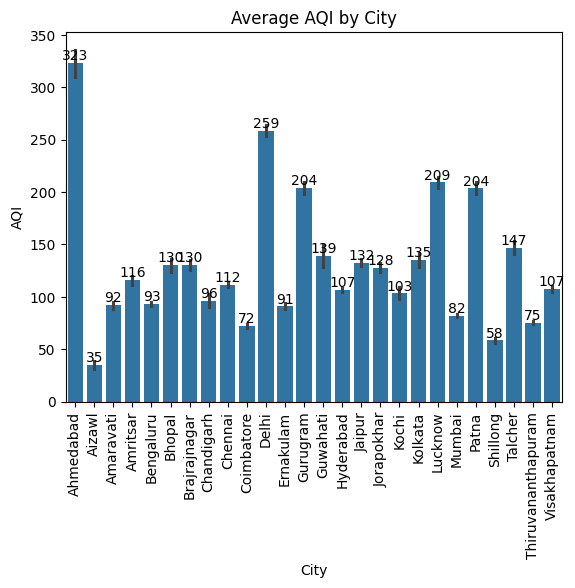

In [30]:
sns.barplot(x='City',y='AQI',data=df)
for label in df['City'].unique():
    plt.text(label,df[df['City']==label]['AQI'].mean(),round(df[df['City']==label]['AQI'].mean()),ha='center',va='bottom')
plt.xticks(rotation=90)
plt.title('Average AQI by City')
plt.show()

Observation
1. We can see from the above visualization that Ahmedabad has the highest AQI value and Aizawl has the lowest value of AQI value
2. The values are 323 for Ahmedabad and 35 for Aizwal

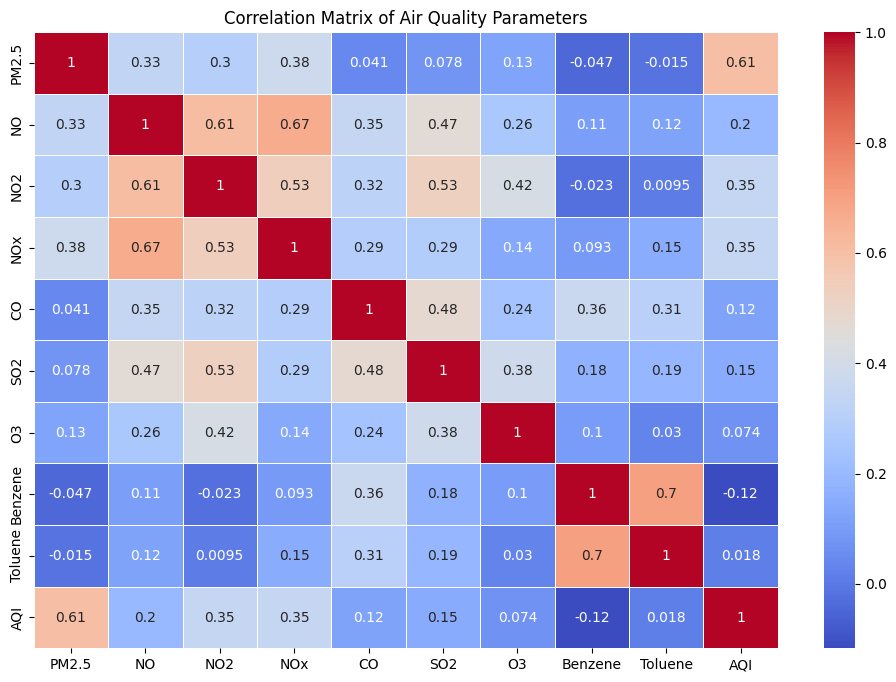

In [31]:
correlation_matrix=df.corr(numeric_only=True)
plt.figure(figsize=(12,8))
sns.heatmap(correlation_matrix,annot=True,cmap='coolwarm',linewidths=0.5)
plt.title('Correlation Matrix of Air Quality Parameters')
plt.show()

Observation
1. The values which has most contribution to AQI are PM2.5 and the value which has the least contribution is Benzene

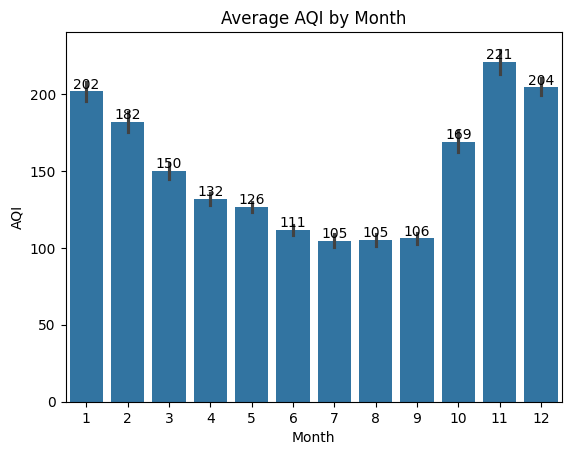

In [35]:
sns.barplot(x='Month',y='AQI',data=df)
for label in df['Month'].unique():
    plt.text(label-1,df[df['Month']==label]['AQI'].mean(),round(df[df['Month']==label]['AQI'].mean()),ha='center',va='bottom')
plt.title('Average AQI by Month')
plt.show()

Observation
1. The Months with the highest AQI value is November and the least AQI Value is July and August
2. The Value are 221 for November and 105 for both August and July
3. This means that the AQI is usually lower in monsoon months and high in winter months 

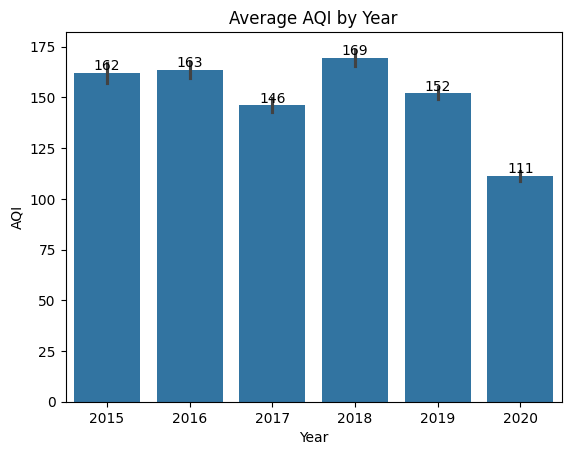

In [36]:
sns.barplot(x='Year',y='AQI',data=df)
for label in df['Year'].unique():
    plt.text(label-2015,df[df['Year']==label]['AQI'].mean(),round(df[df['Year']==label]['AQI'].mean()),ha='center',va='bottom')
plt.title('Average AQI by Year')
plt.show()

Observation
1. The year with the highest AQI value is 2018 and the least AQI value is 2020
2. The values are 169 for 2018 and 111 for 2020
3. The value of 2020 might be low because of covid as people did not travel that much

In [37]:
pt = pd.pivot_table(
    df,
    index='City',
    columns='Year',
    values='AQI',
    aggfunc='mean'
)

pt.head()

Year,2015,2016,2017,2018,2019,2020
City,,,,,,
Ahmedabad,242.903997,145.038781,160.329784,610.103026,500.363993,235.388820
Aizawl,NaN,NaN,NaN,NaN,NaN,35.344258
Amaravati,NaN,NaN,189.222384,96.462687,93.723924,59.879781
Amritsar,NaN,NaN,137.074429,116.694448,109.154388,91.721613
Bengaluru,102.807111,104.021199,87.066988,86.100828,91.602740,79.715847


In [38]:
pt['Change'] = pt.iloc[:, -1] - pt.iloc[:, 0]

improving = pt.sort_values('Change').head(10)

print(improving[['Change']])

Year           Change
City                 
Delhi     -115.352526
Chennai    -48.359871
Hyderabad  -46.357048
Bengaluru  -23.091264
Lucknow    -15.198966
Patna      -12.355769
Ahmedabad   -7.515177
Mumbai      36.117728
Gurugram    91.205160
Aizawl            NaN


Observation
1. The city with the most improvement in air quality is Delhi

In [39]:
worsening = pt.sort_values('Change', ascending=False).head(10)

print(worsening[['Change']])

Year           Change
City                 
Gurugram    91.205160
Mumbai      36.117728
Ahmedabad   -7.515177
Patna      -12.355769
Lucknow    -15.198966
Bengaluru  -23.091264
Hyderabad  -46.357048
Chennai    -48.359871
Delhi     -115.352526
Aizawl            NaN


Observation
1. The city whose air quality has decreased is Gurugram

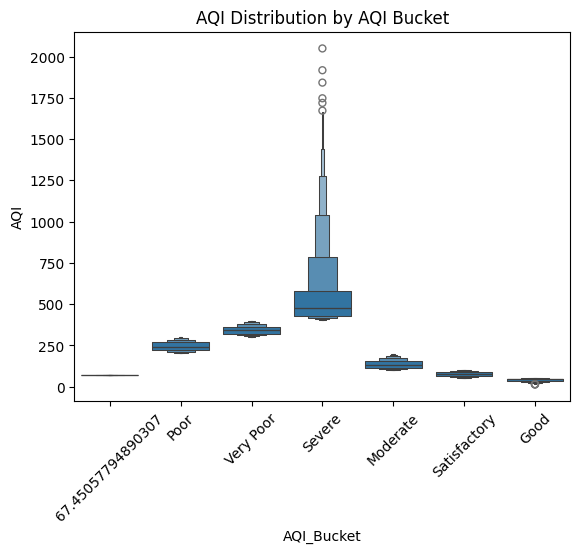

In [40]:
sns.boxenplot(x='AQI_Bucket',y='AQI',data=df)
plt.title('AQI Distribution by AQI Bucket') 
plt.xticks(rotation=45)
plt.show()

Observation
1. The Severe AQI category has the highest pollution levels and the greatest variability.
2. It has the highest median AQI and the widest spread.
3. This indicates that severe pollution events are both intense and highly inconsistent across observations.

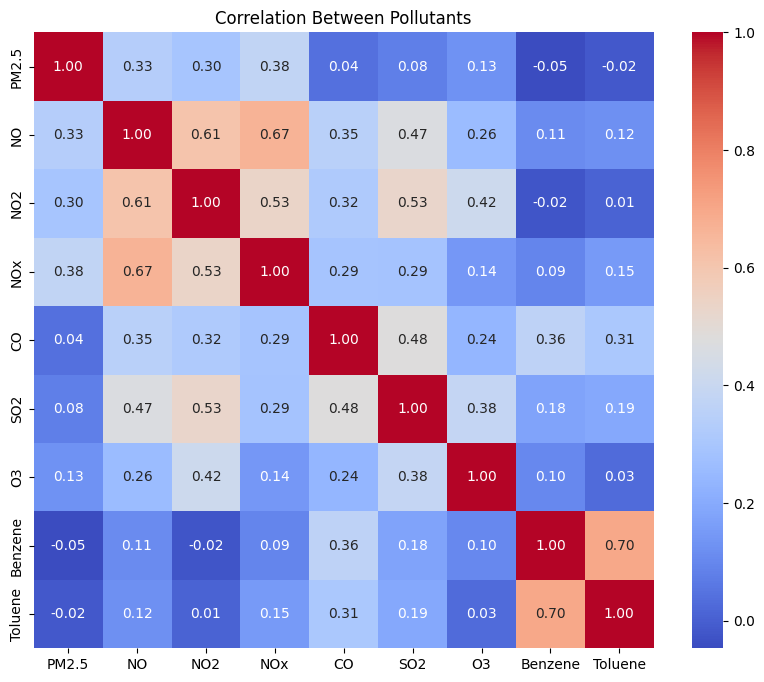

In [43]:
pollutants = ['PM2.5','NO','NO2','NOx','CO','SO2','O3','Benzene','Toluene']

corr = df[pollutants].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Between Pollutants')
plt.show()

Observation
1. Benzene and Toluene exhibited the strongest positive correlation (r = 0.70), indicating they likely originate from similar emission sources.
2. Nitrogen-related pollutants (NO, NO₂, and NOx) showed strong positive correlations (r = 0.53–0.67), suggesting common sources such as vehicular traffic and industrial combustion.

In [44]:
who_limits = {
    'PM2.5': 15,
    'NO2': 25,
    'SO2': 40,
    'CO': 4,
    'O3': 100
}

In [45]:
exceedances = {}

for pollutant, limit in who_limits.items():
    exceedances[pollutant] = (df[pollutant] > limit).sum()

exceed_df = pd.DataFrame(
    exceedances.items(),
    columns=['Pollutant', 'Exceedance_Count']
)

exceed_df.sort_values(
    'Exceedance_Count',
    ascending=False,
    inplace=True
)

print(exceed_df)

  Pollutant  Exceedance_Count
0     PM2.5             27807
1       NO2             14899
2       SO2              5552
3        CO              3931
4        O3               338


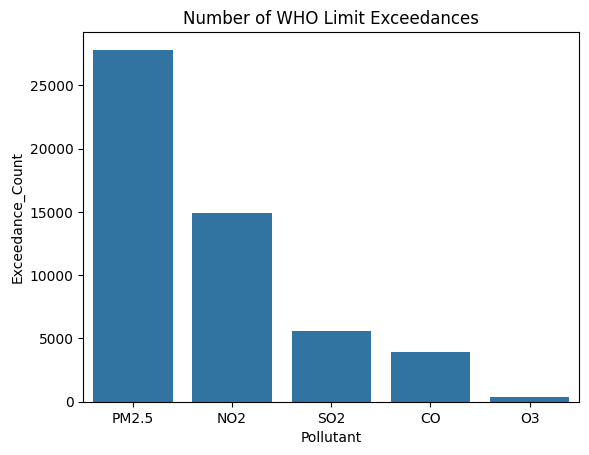

In [46]:
sns.barplot(
    data=exceed_df,
    x='Pollutant',
    y='Exceedance_Count'
)

plt.title('Number of WHO Limit Exceedances')
plt.show()

Observation
1. The pollutants which most exceed the recommend value is PM2.5 and the one which mostly does not exceed the recommend value is o3

Results
1. Most of the Industrial Cities have the highest AQI values
2. There is a decrease in AQI values during the monsoon season and a increase during winter season
3. There is a strong correlation between the PM2.5 pollutant and AQI value
4. There are more cities which have severe problem with AQI than compared to citites which have manganed there AQI
5. The city which has improved its air quality is Delhi 
6. The city whose air quality has decreased is Gurugram
7. There is a strong relation between benzene and Toluene because the are produced mostly from the same process
8. The pollutant that mostly exceeds the WHO limit is PM2.5

Reccomandation
1. Polution in air can be reduced by decreasing the quantity of pollutants like PM2.5 which is the major cause of air pollution
2. Polution is reduced in cities like Delhi and during the year of covid which was 2020 due to less traffic so people should try to increase the usage of public transport 
3. Most of the cities suffer have severe levels of Air polution so there citizens must be encouraged to wear mask to protect them from such pollutants
4. An increase in industrial sites in cities like Gurugram has resulted in its air quality being affected really badly so there must be steps taken so that the industries just can't release polutants into the sky without any consequence
5. Pollutants like NOx are produced by similar processes so if we mange to purify those processes then  many pollutants of the NOx family can be removed from the air similarly we can also remove Benzene and Toluene because they are produced from similar process so 7 out of the 10 mager polutants have similar point of origin and can be removed easily